In [2]:
!pip install dtw-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.9/808.9 kB 4.3 MB/s eta 0:00:00


In [18]:
!git clone --depth 1 https://github.com/Jakobovski/free-spoken-digit-dataset.git fsdd

Cloning into 'fsdd'...
remote: Enumerating objects: 3018, done.
remote: Counting objects: 100% (3018/3018), done.
remote: Compressing objects: 100% (3017/3017), done.
remote: Total 3018 (delta 0), reused 3008 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3018/3018), 15.15 MiB | 23.68 MiB/s, done.


In [19]:
import glob
import numpy as np
import pandas as pd
import librosa
import librosa.display
import pywt
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from dtw import dtw

np.random.seed(7)
plt.rcParams['figure.dpi'] = 100
SR = 8000

archivos = sorted(glob.glob('fsdd/recordings/*.wav'))
print(f'Total de archivos encontrados: {len(archivos)}')

def parse_nombre(path):
    base = path.split('/')[-1].replace('.wav', '')
    digito, hablante, idx = base.split('_')
    return digito, hablante

digitos, hablantes = zip(*[parse_nombre(a) for a in archivos])
df_meta = pd.DataFrame({'archivo': archivos, 'digito': digitos, 'hablante': hablantes})
print(df_meta['digito'].value_counts().sort_index())
print(df_meta['hablante'].value_counts())

Total de archivos encontrados: 3000
digito
0    300
1    300
2    300
3    300
4    300
5    300
6    300
7    300
8    300
9    300
Name: count, dtype: int64
hablante
george      500
jackson     500
lucas       500
nicolas     500
theo        500
yweweler    500
Name: count, dtype: int64


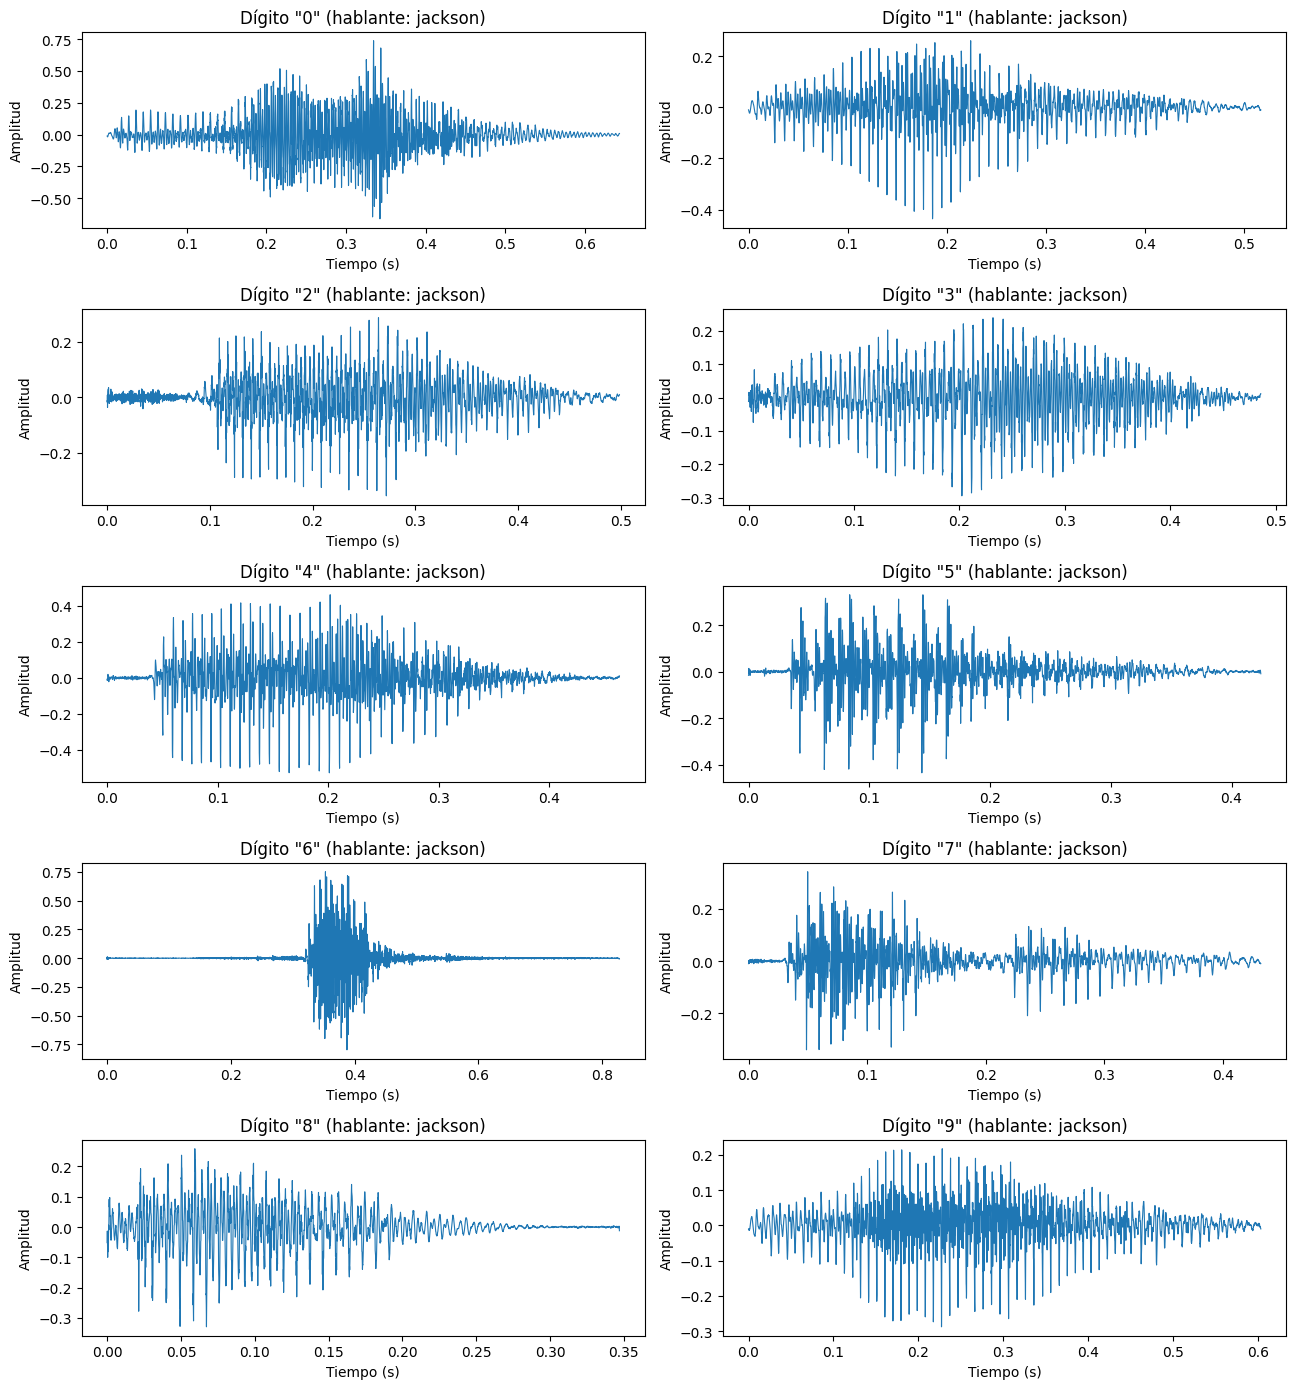

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import matplotlib.pyplot as plt
from google.colab import files

ejemplos = {}
for d in [str(i) for i in range(10)]:
    fila = df_meta[(df_meta.digito == d) & (df_meta.hablante == 'jackson')].iloc[0]
    y, sr = librosa.load(fila.archivo, sr=SR)
    ejemplos[d] = y

fig, axs = plt.subplots(5, 2, figsize=(13, 14), sharex=False)
for ax, d in zip(axs.flat, ejemplos):
    t = np.linspace(0, len(ejemplos[d])/SR, len(ejemplos[d]))
    ax.plot(t, ejemplos[d], linewidth=0.8)
    ax.set_title(f'Dígito "{d}" (hablante: jackson)')
    ax.set_xlabel('Tiempo (s)'); ax.set_ylabel('Amplitud')
plt.tight_layout()
plt.savefig("imagen1.png")
plt.show()
files.download("imagen1.png")

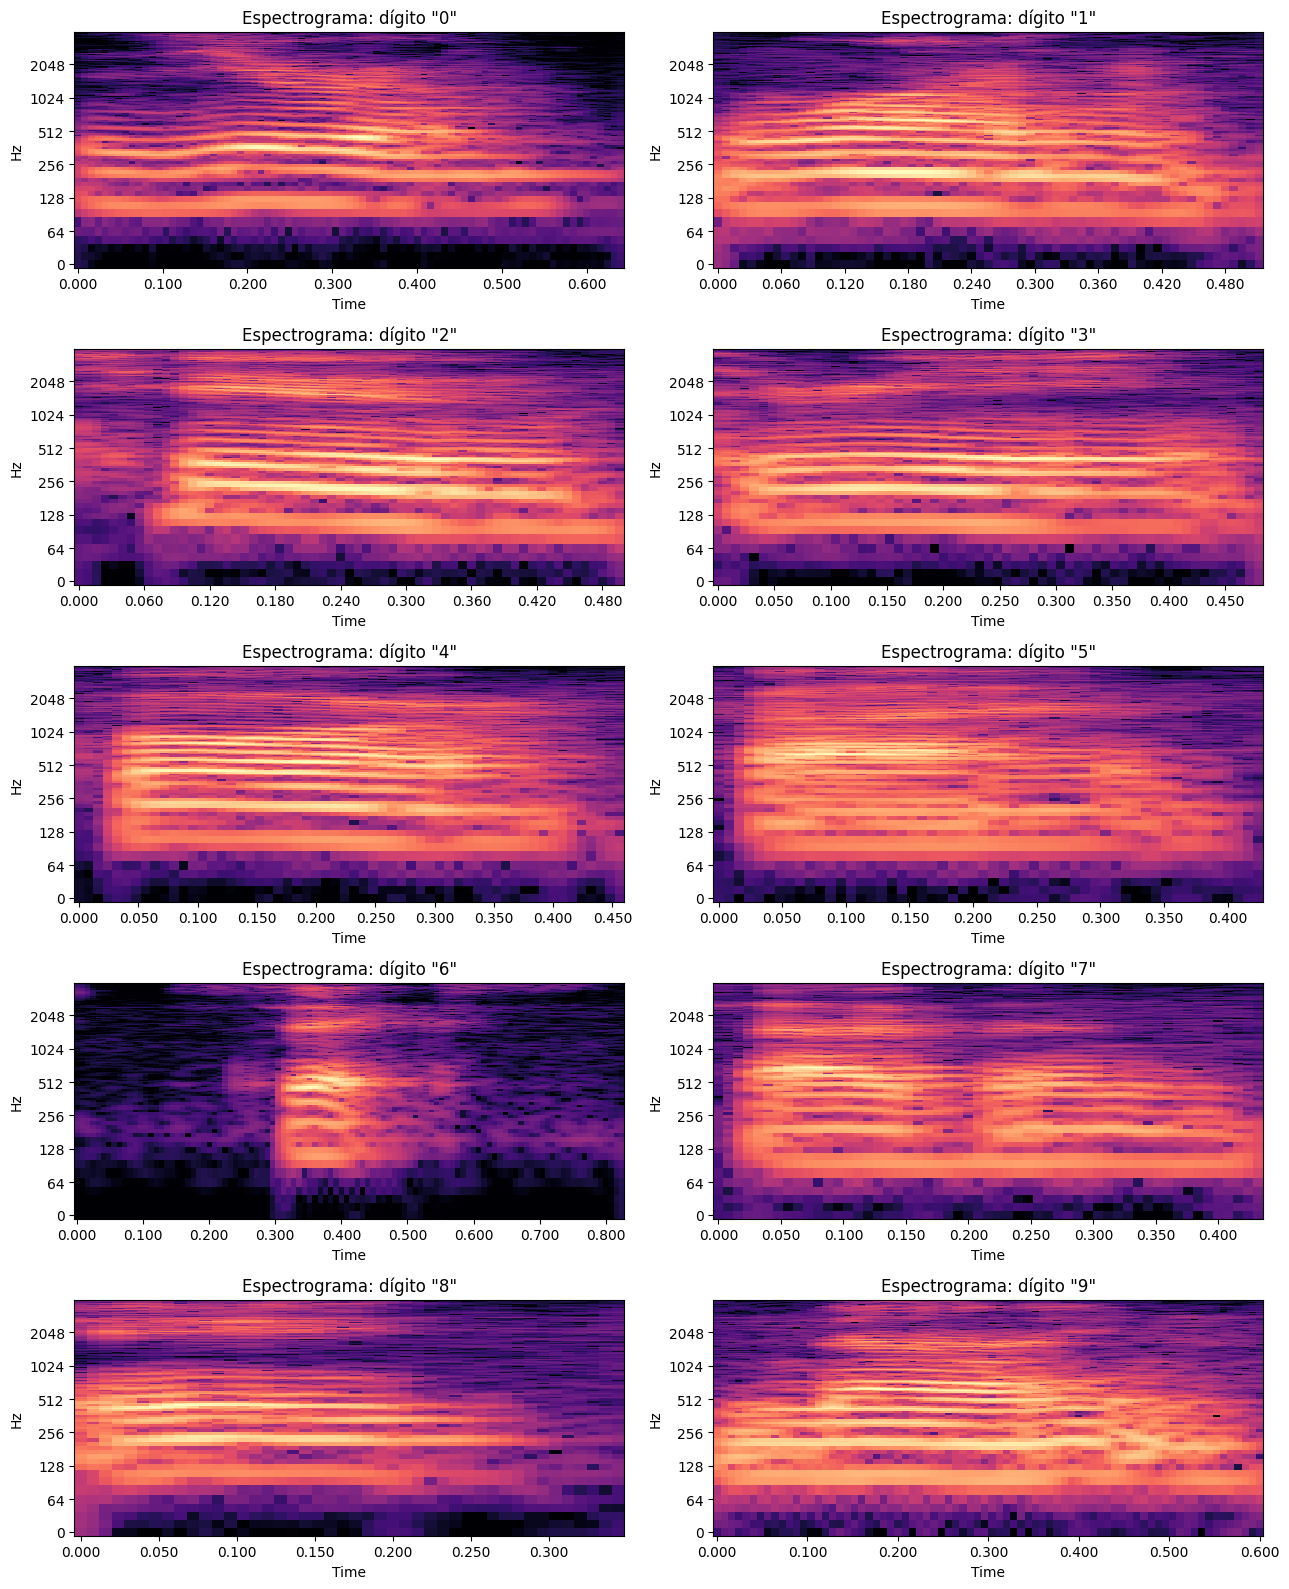

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
fig, axs = plt.subplots(5, 2, figsize=(13, 16))
for ax, d in zip(axs.flat, ejemplos):
    S = librosa.stft(ejemplos[d], n_fft=512, hop_length=64)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    librosa.display.specshow(S_db, sr=SR, x_axis='time', y_axis='log', ax=ax, hop_length=64)
    ax.set_title(f'Espectrograma: dígito "{d}"')
plt.tight_layout()
plt.savefig("imagen2.png")
plt.show()
files.download("imagen2.png")

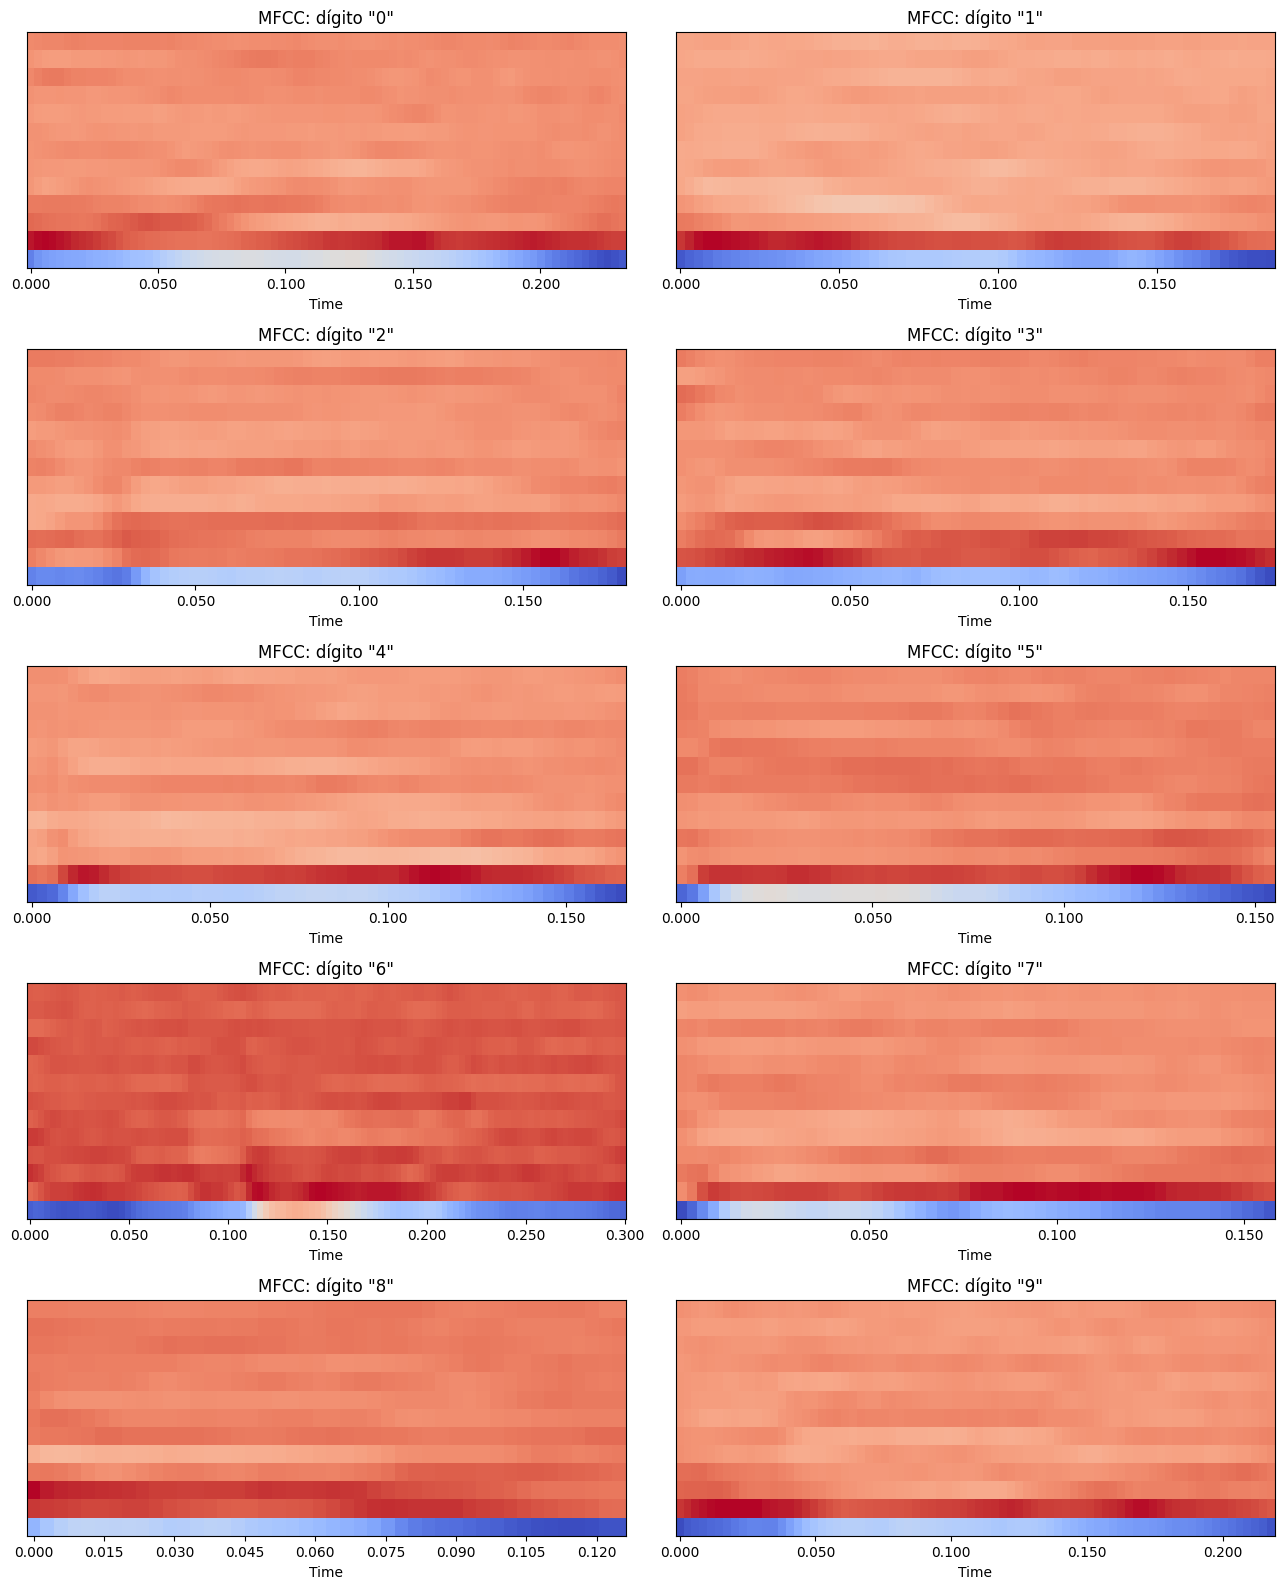

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
fig, axs = plt.subplots(5, 2, figsize=(13, 16))
for ax, d in zip(axs.flat, ejemplos):
    mfccs = librosa.feature.mfcc(y=ejemplos[d], sr=SR, n_mfcc=13, n_fft=512, hop_length=64)
    librosa.display.specshow(mfccs, x_axis='time', ax=ax, hop_length=64)
    ax.set_title(f'MFCC: dígito "{d}"')
plt.tight_layout()
plt.savefig("imagen3.png")
plt.show()
files.download("imagen3.png")

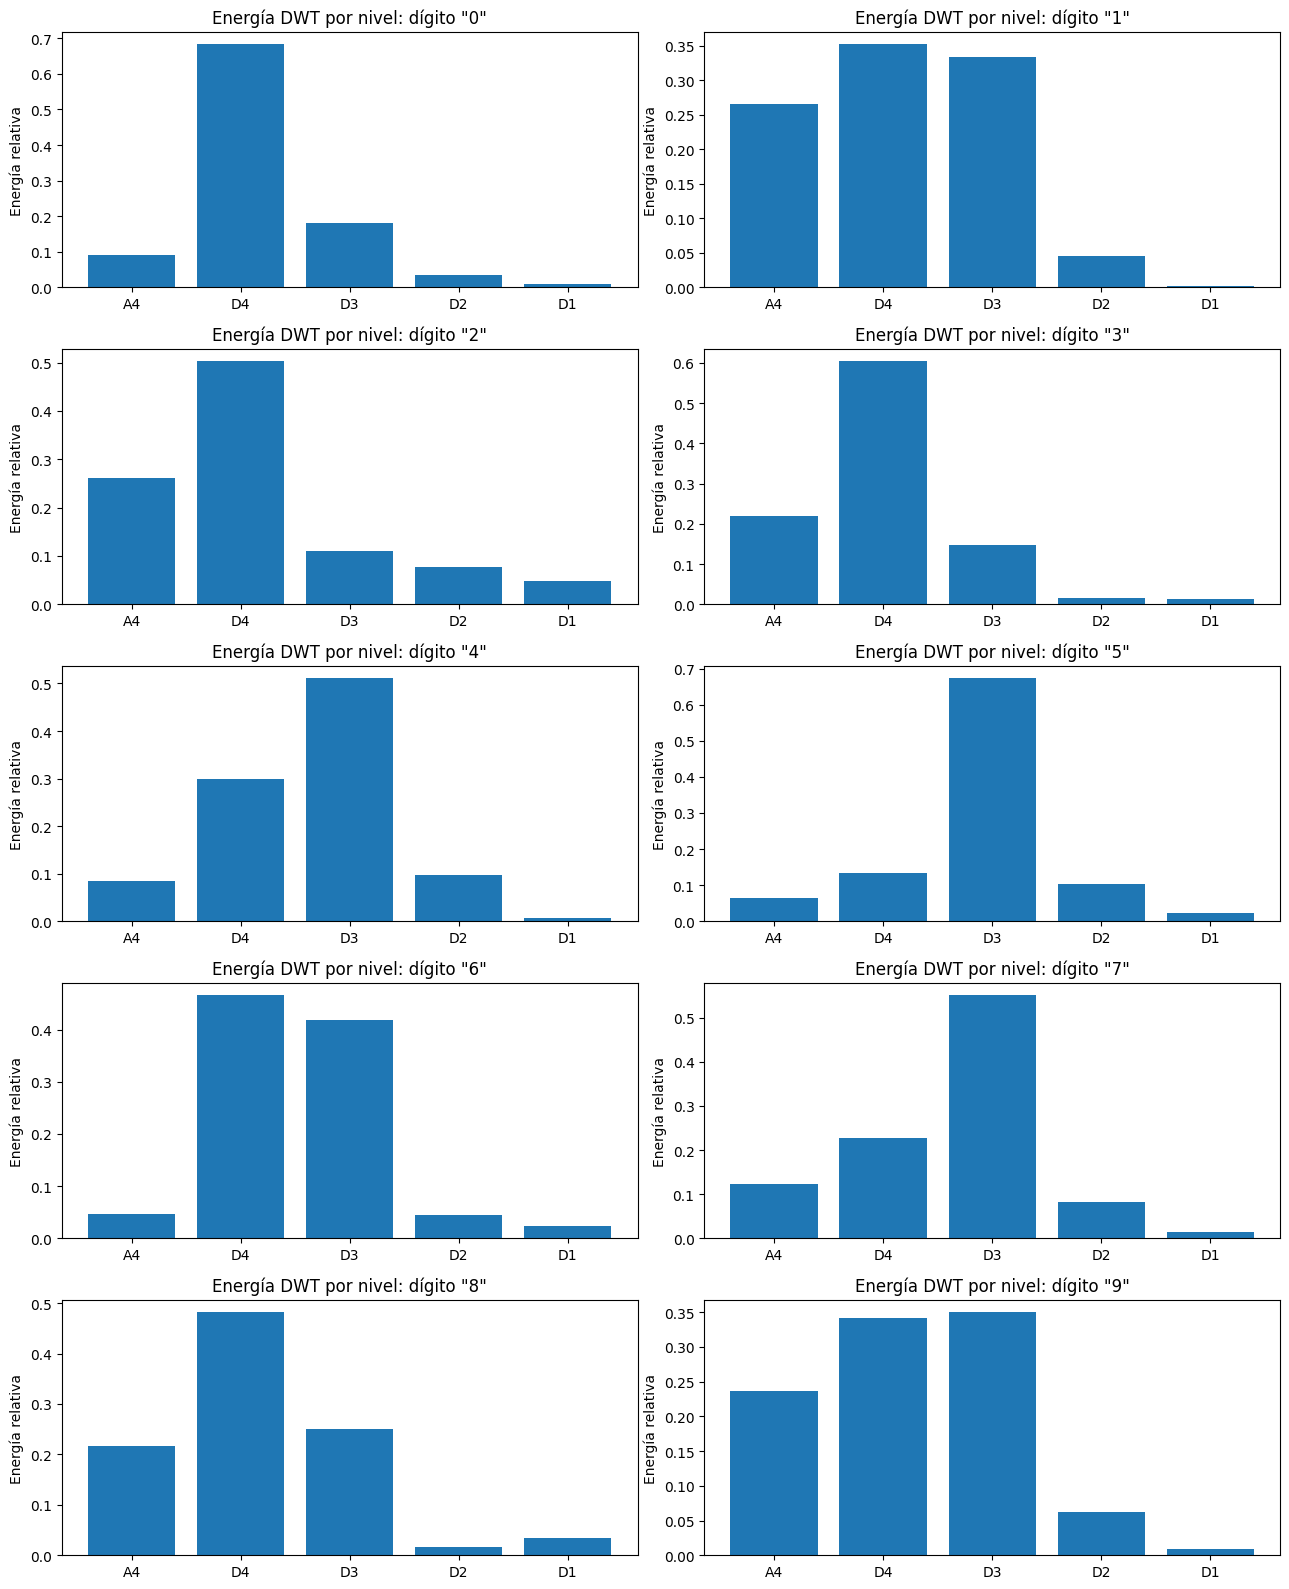

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
fig, axs = plt.subplots(5, 2, figsize=(13, 16))
for ax, d in zip(axs.flat, ejemplos):
    coeffs = pywt.wavedec(ejemplos[d], 'db4', level=4)
    energia = np.array([np.sum(c**2) for c in coeffs])
    energia = energia / energia.sum()
    niveles = ['A4', 'D4', 'D3', 'D2', 'D1']
    ax.bar(niveles, energia)
    ax.set_title(f'Energía DWT por nivel: dígito "{d}"')
    ax.set_ylabel('Energía relativa')
plt.tight_layout()
plt.savefig("imagen4.png")
plt.show()
files.download("imagen4.png")

In [25]:
def extraer_caracteristicas(path, sr_target=SR):
    y, sr = librosa.load(path, sr=sr_target)
    if len(y) < 512:
        y = np.pad(y, (0, 512 - len(y)))

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=512, hop_length=128)
    mfcc_mean, mfcc_std = mfccs.mean(axis=1), mfccs.std(axis=1)

    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=512, hop_length=128).mean()
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=512, hop_length=128).mean()
    zcr = librosa.feature.zero_crossing_rate(y).mean()
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=512, hop_length=128).mean()
    flatness = librosa.feature.spectral_flatness(y=y, n_fft=512, hop_length=128).mean()
    duracion = len(y) / sr

    coeffs = pywt.wavedec(y, 'db4', level=4)
    energia_dwt = np.array([np.sum(c**2) for c in coeffs])
    energia_dwt = energia_dwt / (energia_dwt.sum() + 1e-9)

    return np.concatenate([mfcc_mean, mfcc_std,
                            [centroid, bandwidth, zcr, rolloff, flatness, duracion],
                            energia_dwt])

X_feat = np.array([extraer_caracteristicas(a) for a in df_meta.archivo])
y_digito = df_meta.digito.values
y_hablante = df_meta.hablante.values
print('Matriz de características:', X_feat.shape)
print('26 MFCC (media+std) + 6 estadísticos (incl. duración) + 5 energías DWT = 37 features')

Matriz de características: (3000, 37)
26 MFCC (media+std) + 6 estadísticos (incl. duración) + 5 energías DWT = 37 features


In [26]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X_feat)

X_train, X_test, y_train, y_test = train_test_split(
    Xs, y_digito, test_size=0.2, random_state=7, stratify=y_digito)

print(f'Train: {X_train.shape[0]} audios | Test: {X_test.shape[0]} audios')

modelos = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=7),
    'SVM-RBF': SVC(kernel='rbf', C=10, gamma='scale'),
}

resultados = {}
CLASES = [str(i) for i in range(10)]
for nombre, clf in modelos.items():
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    resultados[nombre] = {'modelo': clf, 'pred': pred, 'acc': acc}
    print(f'\n=== {nombre} | accuracy = {acc:.3f} ===')
    print(classification_report(y_test, pred, zero_division=0))

Train: 2400 audios | Test: 600 audios

=== RandomForest | accuracy = 0.973 ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        60
           1       0.97      0.98      0.98        60
           2       0.97      0.98      0.98        60
           3       0.95      0.97      0.96        60
           4       1.00      1.00      1.00        60
           5       0.97      0.97      0.97        60
           6       0.98      0.92      0.95        60
           7       0.97      1.00      0.98        60
           8       0.95      0.97      0.96        60
           9       0.98      0.98      0.98        60

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600


=== SVM-RBF | accuracy = 0.988 ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        60
           1     

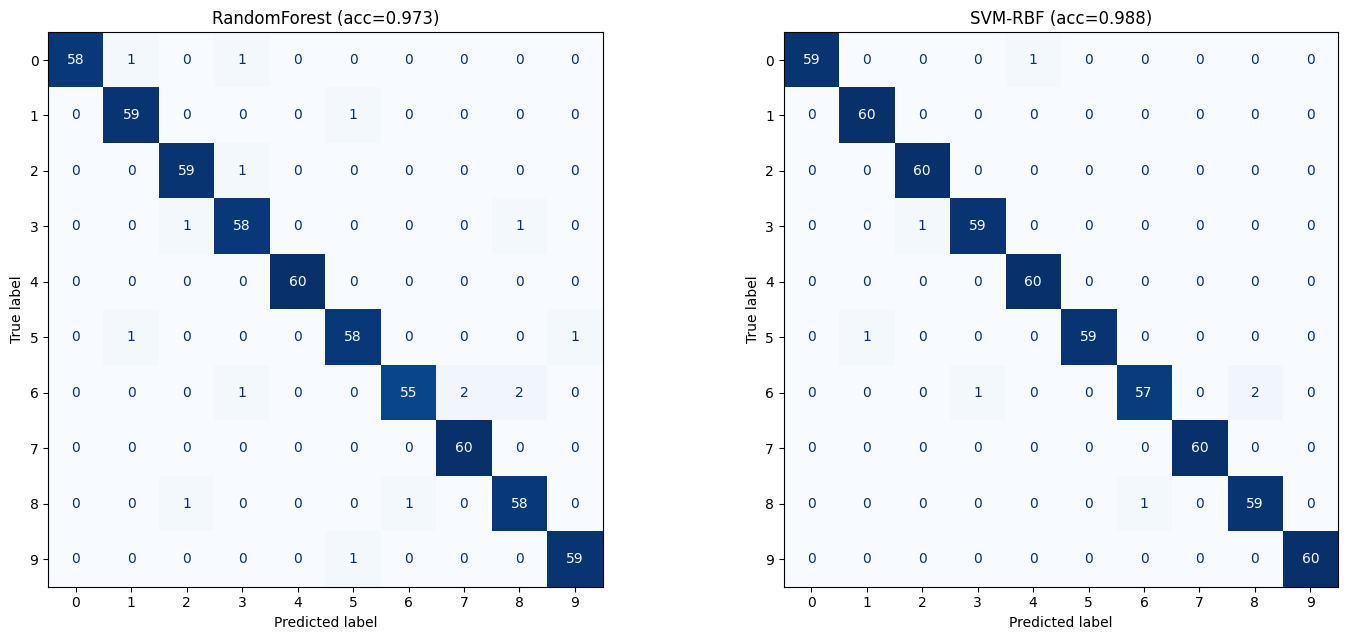

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, (nombre, res) in zip(axs, resultados.items()):
    cm = confusion_matrix(y_test, res['pred'], labels=CLASES)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{nombre} (acc={res['acc']:.3f})")
plt.tight_layout()
plt.savefig("imagen5.png")
plt.show()
files.download("imagen5.png")

Par más confundido por SVM: dígito "6" <-> dígito "8" (2 confusiones)
DTW intra-dígito: media=15.87, std=9.95
DTW inter-dígito (6 vs 8): media=15.50, std=10.28


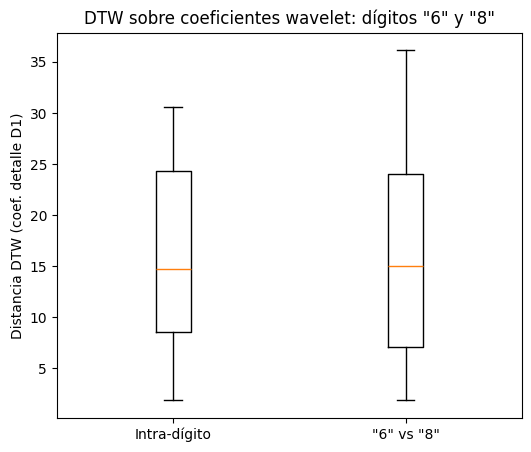

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
cm_svm = confusion_matrix(y_test, resultados['SVM-RBF']['pred'], labels=CLASES)
np.fill_diagonal(cm_svm, 0)
i, j = np.unravel_index(np.argmax(cm_svm), cm_svm.shape)
d1, d2 = CLASES[i], CLASES[j]
print(f'Par más confundido por SVM: dígito "{d1}" <-> dígito "{d2}" ({cm_svm[i,j]} confusiones)')

def detalle_d1(y):
    coeffs = pywt.wavedec(y, 'db4', level=4)
    return coeffs[-1]

archivos_d1 = df_meta[df_meta.digito == d1].archivo.sample(8, random_state=7).tolist()
archivos_d2 = df_meta[df_meta.digito == d2].archivo.sample(8, random_state=7).tolist()

wave_d1 = [detalle_d1(librosa.load(a, sr=SR)[0]) for a in archivos_d1]
wave_d2 = [detalle_d1(librosa.load(a, sr=SR)[0]) for a in archivos_d2]

def dtw_dist(a, b):
    return dtw(a, b, keep_internals=False).distance

intra = [dtw_dist(wave_d1[a], wave_d1[b]) for a in range(8) for b in range(a+1, 8)]
intra += [dtw_dist(wave_d2[a], wave_d2[b]) for a in range(8) for b in range(a+1, 8)]
inter = [dtw_dist(wave_d1[a], wave_d2[b]) for a in range(8) for b in range(8)]

print(f'DTW intra-dígito: media={np.mean(intra):.2f}, std={np.std(intra):.2f}')
print(f'DTW inter-dígito ({d1} vs {d2}): media={np.mean(inter):.2f}, std={np.std(inter):.2f}')

plt.figure(figsize=(6,5))
plt.boxplot([intra, inter], tick_labels=[f'Intra-dígito', f'"{d1}" vs "{d2}"'])
plt.ylabel('Distancia DTW (coef. detalle D1)')
plt.title(f'DTW sobre coeficientes wavelet: dígitos "{d1}" y "{d2}"')
plt.savefig("imagen6.png")
plt.show()
files.download("imagen6.png")

In [30]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    Xs, y_hablante, test_size=0.2, random_state=7, stratify=y_hablante)

clf_hablante = RandomForestClassifier(n_estimators=300, random_state=7)
clf_hablante.fit(X_train_h, y_train_h)
pred_h = clf_hablante.predict(X_test_h)
acc_h = accuracy_score(y_test_h, pred_h)
print(f'Accuracy identificación de hablante (RandomForest): {acc_h:.3f}')
print(classification_report(y_test_h, pred_h, zero_division=0))

Accuracy identificación de hablante (RandomForest): 0.988
              precision    recall  f1-score   support

      george       1.00      1.00      1.00       100
     jackson       0.98      1.00      0.99       100
       lucas       1.00      1.00      1.00       100
     nicolas       1.00      1.00      1.00       100
        theo       0.99      0.95      0.97       100
    yweweler       0.96      0.98      0.97       100

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600

